In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

plt.style.use('../../my_style.mplstyle')

# スタイルからカラーマップ名を取得して Colormap オブジェクトを作成
cmap_name = plt.rcParams.get('image.cmap', 'cividis')
cmap = plt.get_cmap(cmap_name)
print(f"Using colormap from style: {cmap_name}")

folder = os.path.join("..", "data", "MT")
files = sorted(glob.glob(os.path.join(folder, "*")))

S_list = []

for file in files:
    path = os.path.join(file, "order_param.npy")
    if not os.path.exists(path):
        print(f"Skipping missing file: {path}")
        continue
    S=np.load(path)
    S_list.append(S)


Using colormap from style: cividis


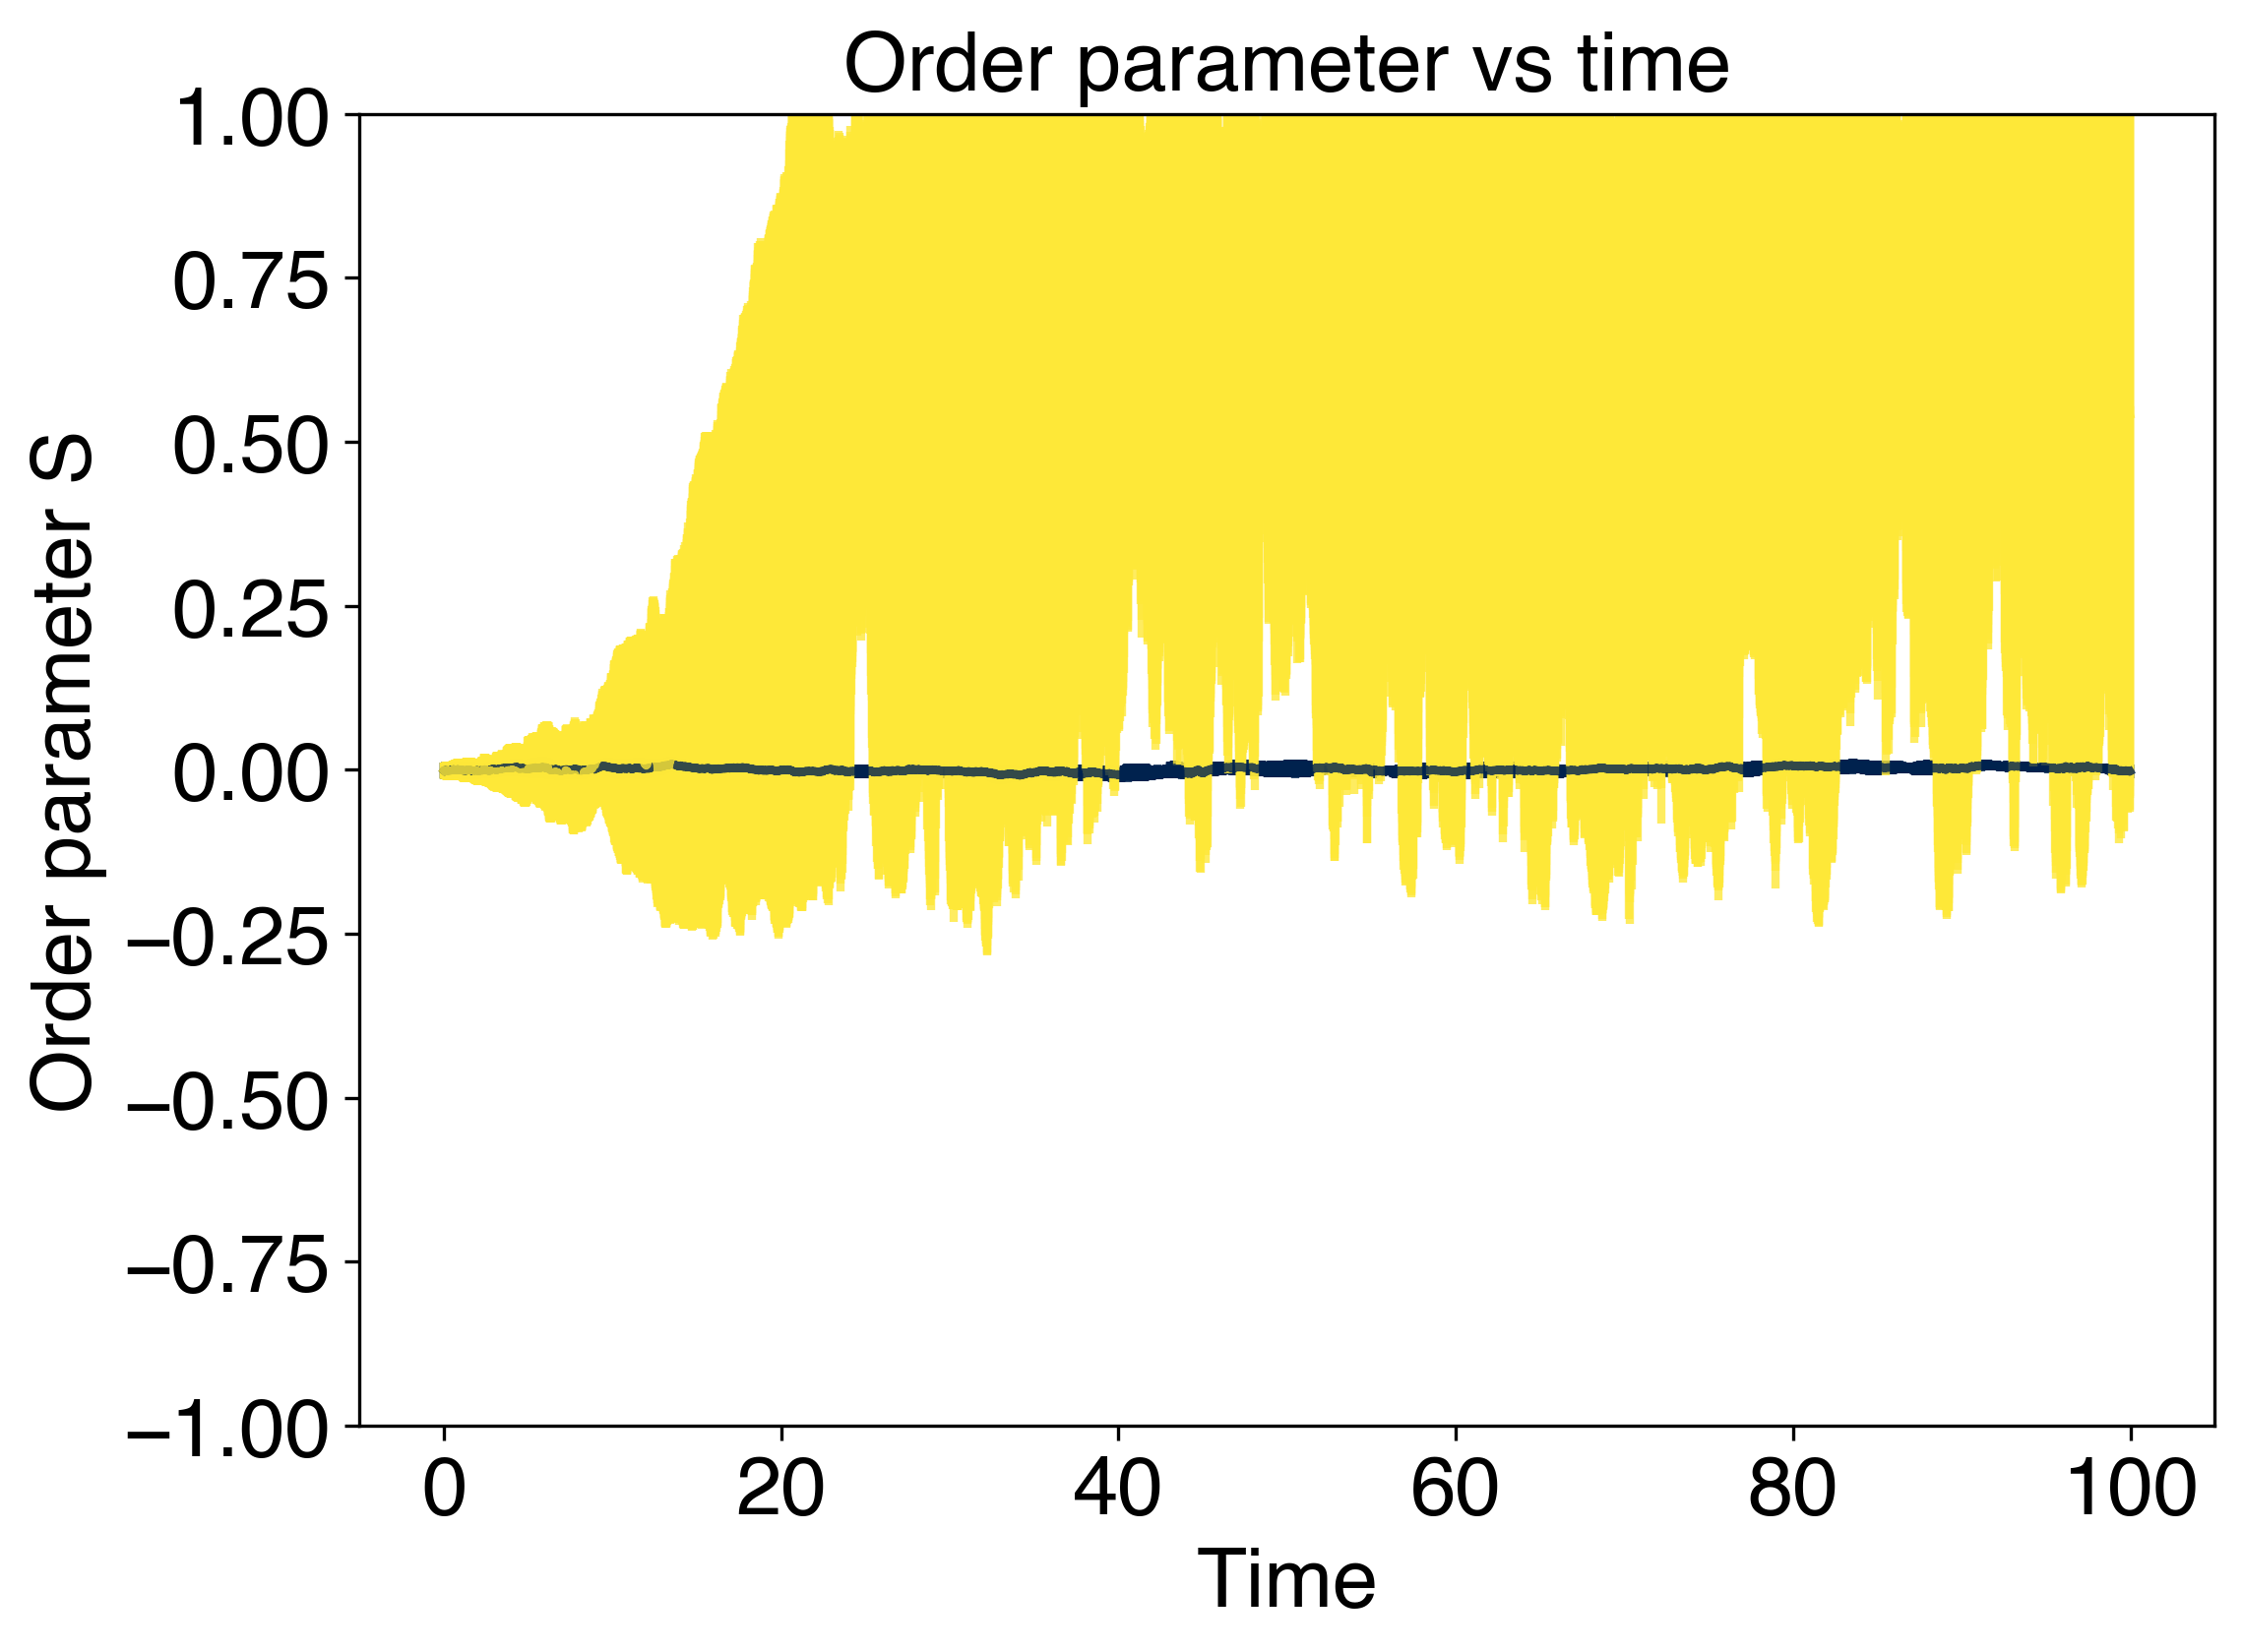

In [2]:
fig, ax = plt.subplots()

if len(S_list) == 0:
    print("No data found to plot.")
else:
    n = len(S_list)
    colors = cmap(np.linspace(0, 1, n))

    for idx, S_array in enumerate(S_list):
        S_em = np.mean(S_array, axis = 0)
        S_std = np.std(S_array, axis = 0)

        x = np.arange(S_em.size) * 0.01  # 時間刻み（必要に応じて調整）
        ax.errorbar(x, S_em, S_std, color=colors[idx], alpha=0.8)

    ax.set_ylim((-1,1))
    ax.set_xlabel('Time')
    ax.set_ylabel('Order parameter S')
    ax.set_title('Order parameter vs time')

plt.show()
